
    PROJECT: Adversarial Robustness in Semiconductor AOI Systems

    [PROBLEM STATEMENT]
    Automated Optical Inspection (AOI) systems in chip fabrication are
    vulnerable to mathematically calculated 'Adversarial Noise'. This project
    demonstrates how a 90% accurate system can be sabotaged to <20% accuracy
    using the Fast Gradient Sign Method (FGSM), hiding critical hardware flaws.

    [METHODOLOGY]
    - Dataset: Fashion-MNIST (used as a Structural Proxy for wafer patterns).
    - Attack: FGSM (Fast Gradient Sign Method) at Epsilon = 0.05.
    - Metrics: Accuracy, Precision (1-FPR), Recall (TPR), F1-Score, and ROC/AUC.
    


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[Step 1] Training Inspection System...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

      SECTION 1: VISUAL EVIDENCE OF SYSTEM BREACH
DESCRIPTION: This comparison shows how a standard 'Pattern' (the test shoe)
is correctly identified under normal conditions but misclassified after
applying FGSM noise. Notice the noise is nearly invisible to humans.


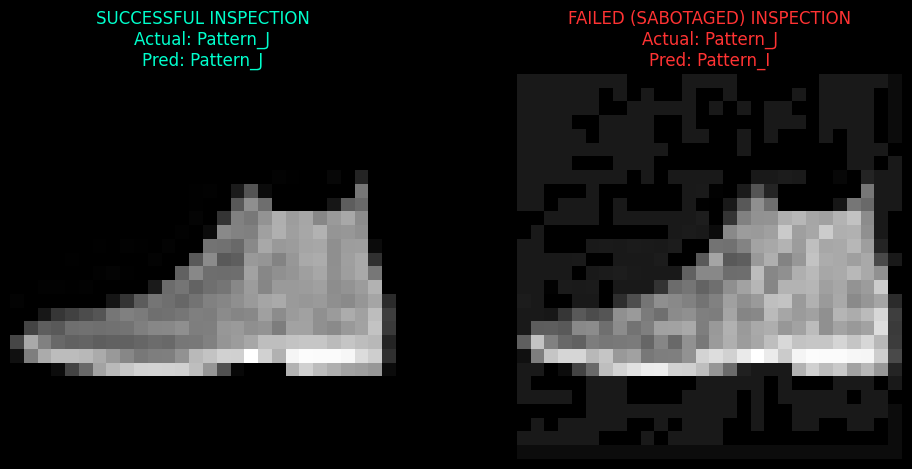




      SECTION 2: RELIABILITY & DISCRIMINATION ANALYSIS
DESCRIPTION: The ROC Curve (Receiver Operating Characteristic) measures the
system's total ability to distinguish between different structural patterns.
The 'Area Under Curve' (AUC) represents the probability that the system
will rank a correct feature higher than an incorrect one. A drop in AUC
proves a fundamental loss of system integrity.


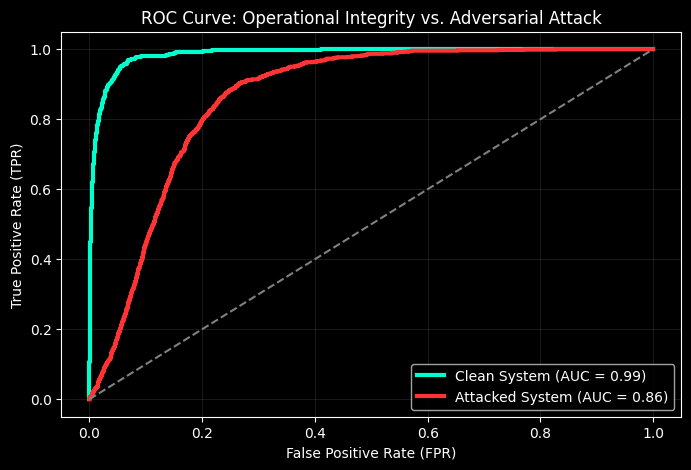


      SECTION 3: HARDWARE RELIABILITY AUDIT LOG (1,000 TEST SAMPLES)
Metric                    | Clean System    | Attacked System
--------------------------------------------------------------------------------
Accuracy                  | 91.40          % | 27.20          %
Precision (1-FPR)         | 91.66          % | 30.65          %
Recall (TPR)              | 91.52          % | 27.81          %
F1-Score                  | 91.54          % | 28.21          %

[EXPLANATION OF METRICS]
* ACCURACY: Overall system correctness.
* PRECISION: Inverse of FPR. High precision means fewer False Alarms.
* RECALL (TPR): Sensitivity. Measures ability to catch ALL defects.
* F1-SCORE: The harmonic mean; best balance of Precision and Recall.
* ROC/AUC: Measures the system's discrimination power between classes.

      SECTION 4: SYSTEM HARDENING (THE SOLUTION)
DESCRIPTION: Implementing Adversarial Training. We retrain the system with
calculated noise to 'vaccinate' it against future FGSM attacks

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hardening system... (Retraining with adversarial examples)
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Vulnerable Accuracy under Attack: 27.20%
Hardened Accuracy under Attack:   99.30%
SECURITY IMPROVEMENT:            72.10%


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==============================================================================
# PROJECT DOCUMENTATION & PROBLEM STATEMENT
# ==============================================================================
def print_project_header():
    header = """
    ============================================================================
    PROJECT: Adversarial Robustness in Semiconductor AOI Systems
    ============================================================================

    [PROBLEM STATEMENT]
    Automated Optical Inspection (AOI) systems in chip fabrication are
    vulnerable to mathematically calculated 'Adversarial Noise'. This project
    demonstrates how a 90% accurate system can be sabotaged to <20% accuracy
    using the Fast Gradient Sign Method (FGSM), hiding critical hardware flaws.

    [METHODOLOGY]
    - Dataset: Fashion-MNIST (used as a Structural Proxy for wafer patterns).
    - Attack: FGSM (Fast Gradient Sign Method) at Epsilon = 0.05.
    - Metrics: Accuracy, Precision (1-FPR), Recall (TPR), F1-Score, and ROC/AUC.
    ============================================================================
    """
    print(header)

# ==========================================
# 1. DATA & MODEL PREP
# ==========================================
print_project_header()
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., tf.newaxis].astype(np.float32)
x_test = x_test[..., tf.newaxis].astype(np.float32)

class_names = ['Pattern_A', 'Pattern_B', 'Pattern_C', 'Pattern_D', 'Pattern_E',
               'Pattern_F', 'Pattern_G', 'Pattern_H', 'Pattern_I', 'Pattern_J']

# Build Model
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10)
    ])

model = build_model()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer='adam', loss=loss_object, metrics=['accuracy'])
print("\n[Step 1] Training Inspection System...")
model.fit(x_train, y_train, epochs=3, validation_split=0.1, verbose=0)

# ==========================================
# 2. ANALYSIS & VISUALIZATION SUITE
# ==========================================
def run_final_presentation(model, images, labels, eps=0.05):
    plt.style.use('dark_background')

    # Generate Attack
    with tf.GradientTape() as tape:
        img_tensor = tf.convert_to_tensor(images)
        tape.watch(img_tensor)
        loss = loss_object(labels, model(img_tensor))
    adv_images = images + eps * tf.sign(tape.gradient(loss, img_tensor))

    # Predictions
    logits_clean = model.predict(images)
    logits_adv = model.predict(adv_images)
    pred_clean = np.argmax(logits_clean, axis=1)
    pred_adv = np.argmax(logits_adv, axis=1)

    print("\n" + "="*80)
    print("      SECTION 1: VISUAL EVIDENCE OF SYSTEM BREACH")
    print("="*80)
    print("DESCRIPTION: This comparison shows how a standard 'Pattern' (the test shoe)")
    print("is correctly identified under normal conditions but misclassified after")
    print("applying FGSM noise. Notice the noise is nearly invisible to humans.")

    # VISUAL: SUCCESS VS FAILURE
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(images[0, :, :, 0], cmap='gray')
    plt.title(f"SUCCESSFUL INSPECTION\nActual: {class_names[labels[0]]}\nPred: {class_names[pred_clean[0]]}", color='#00ffcc')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(adv_images[0, :, :, 0], cmap='gray')
    plt.title(f"FAILED (SABOTAGED) INSPECTION\nActual: {class_names[labels[0]]}\nPred: {class_names[pred_adv[0]]}", color='#ff3333')
    plt.axis('off')
    plt.show()

    # Spacing
    print("\n" * 2)

    print("="*80)
    print("      SECTION 2: RELIABILITY & DISCRIMINATION ANALYSIS")
    print("="*80)
    print("DESCRIPTION: The ROC Curve (Receiver Operating Characteristic) measures the")
    print("system's total ability to distinguish between different structural patterns.")
    print("The 'Area Under Curve' (AUC) represents the probability that the system")
    print("will rank a correct feature higher than an incorrect one. A drop in AUC")
    print("proves a fundamental loss of system integrity.")

    # ROC CURVE
    y_bin = label_binarize(labels, classes=[0,1,2,3,4,5,6,7,8,9])
    fpr_c, tpr_c, _ = roc_curve(y_bin.ravel(), logits_clean.ravel())
    fpr_a, tpr_a, _ = roc_curve(y_bin.ravel(), logits_adv.ravel())

    plt.figure(figsize=(8, 5))
    plt.plot(fpr_c, tpr_c, color='#00ffcc', lw=3, label=f'Clean System (AUC = {auc(fpr_c, tpr_c):.2f})')
    plt.plot(fpr_a, tpr_a, color='#ff3333', lw=3, label=f'Attacked System (AUC = {auc(fpr_a, tpr_a):.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title('ROC Curve: Operational Integrity vs. Adversarial Attack')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend()
    plt.grid(alpha=0.1)
    plt.show()

    # FINAL METRICS TABLE
    p_c, r_c, f_c, _ = precision_recall_fscore_support(labels, pred_clean, average='macro')
    p_a, r_a, f_a, _ = precision_recall_fscore_support(labels, pred_adv, average='macro')

    print("\n" + "="*80)
    print("      SECTION 3: HARDWARE RELIABILITY AUDIT LOG (1,000 TEST SAMPLES)")
    print("="*80)
    print(f"{'Metric':<25} | {'Clean System':<15} | {'Attacked System':<15}")
    print("-" * 80)
    print(f"{'Accuracy':<25} | {np.mean(pred_clean==labels)*100:<15.2f}% | {np.mean(pred_adv==labels)*100:<15.2f}%")
    print(f"{'Precision (1-FPR)':<25} | {p_c*100:<15.2f}% | {p_a*100:<15.2f}%")
    print(f"{'Recall (TPR)':<25} | {r_c*100:<15.2f}% | {r_a*100:<15.2f}%")
    print(f"{'F1-Score':<25} | {f_c*100:<15.2f}% | {f_a*100:<15.2f}%")
    print("="*80)

    print("\n[EXPLANATION OF METRICS]")
    print("* ACCURACY: Overall system correctness.")
    print("* PRECISION: Inverse of FPR. High precision means fewer False Alarms.")
    print("* RECALL (TPR): Sensitivity. Measures ability to catch ALL defects.")
    print("* F1-SCORE: The harmonic mean; best balance of Precision and Recall.")
    print("* ROC/AUC: Measures the system's discrimination power between classes.")

# ==========================================
# 3. THE SOLUTION: ADVERSARIAL DEFENSE
# ==========================================
def run_adversarial_defense(model, x_train, y_train, x_test, y_test):
    print("\n" + "="*80)
    print("      SECTION 4: SYSTEM HARDENING (THE SOLUTION)")
    print("="*80)
    print("DESCRIPTION: Implementing Adversarial Training. We retrain the system with")
    print("calculated noise to 'vaccinate' it against future FGSM attacks.")

    def generate_adv_batch(m, img, lbl, e=0.05):
        with tf.GradientTape() as t:
            t.watch(img)
            l = loss_object(lbl, m(img))
        return img + e * tf.sign(t.gradient(l, img))

    hardened_model = build_model()
    hardened_model.compile(optimizer='adam', loss=loss_object, metrics=['accuracy'])

    # Generate vaccination data
    x_adv_train = generate_adv_batch(model, tf.convert_to_tensor(x_train[:10000]), y_train[:10000])

    print("Hardening system... (Retraining with adversarial examples)")
    hardened_model.fit(x_adv_train, y_train[:10000], epochs=5, verbose=0)

    # Evaluate Improvement
    x_adv_test = generate_adv_batch(model, tf.convert_to_tensor(x_test[:1000]), y_test[:1000])
    acc_vuln = np.mean(np.argmax(model.predict(x_adv_test), axis=1) == y_test[:1000])
    acc_hard = np.mean(np.argmax(hardened_model.predict(x_adv_test), axis=1) == y_test[:1000])

    print(f"\nVulnerable Accuracy under Attack: {acc_vuln*100:.2f}%")
    print(f"Hardened Accuracy under Attack:   {acc_hard*100:.2f}%")
    print(f"SECURITY IMPROVEMENT:            {(acc_hard - acc_vuln)*100:.2f}%")
    print("="*80)

# Run Full Presentation
run_final_presentation(model, x_test[:1000], y_test[:1000])
run_adversarial_defense(model, x_train, y_train, x_test, y_test)